# 2-1. 미니 프로젝트 : 가위바위보 분류기를 만들자

## 환경설정 및 라이브러리 버전 확인

In [191]:
import sys, typing_extensions
print(sys.executable)
print(typing_extensions.__file__)

d:\git\01_mdls_ds8_open\08_dl\260305_dl_mini-project_rock scissor paper\venv\Scripts\python.exe
d:\git\01_mdls_ds8_open\08_dl\260305_dl_mini-project_rock scissor paper\venv\Lib\site-packages\typing_extensions.py


In [192]:
# pip install "tensorflow>=2.12,<2.13" -> 한번만 설치하면됨 
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

# LMS 버전 
# tensorflow 2.6.0
# numpy 1.22.2

2.12.1
1.24.3


## 데이터 준비
- 구글 teachable machine 사이트 :"https://teachablemachine.withgoogle.com/
- LMS aiffle 클라우드 제공 데이터셋 

## 데이터 불러오기 + Resize

In [193]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [194]:
def resize_images(img_path):
    images = glob.glob(img_path + "/*.jpg")  

    print(len(images), " images to be resized.")

    target_size = (28, 28)
    for img in images:
        old_img = Image.open(img)
        new_img = old_img.resize(target_size, Image.LANCZOS)  # 수정된 부분[web:12][web:18]
        new_img.save(img, "JPEG")

    print(len(images), " images resized.")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/scissor/"
resize_images(image_dir_path)
print("가위 이미지 resize 완료!")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/rock"
resize_images(image_dir_path)

print("바위 이미지 resize 완료!")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/paper"
resize_images(image_dir_path)

print("보 이미지 resize 완료!")

100  images to be resized.
100  images resized.
가위 이미지 resize 완료!
100  images to be resized.
100  images resized.
바위 이미지 resize 완료!
100  images to be resized.
100  images resized.
보 이미지 resize 완료!


In [195]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=28
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/"
(x_train, y_train)=load_data(image_dir_path)
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_train shape: (300, 28, 28, 3)
y_train shape: (300,)


라벨:  0


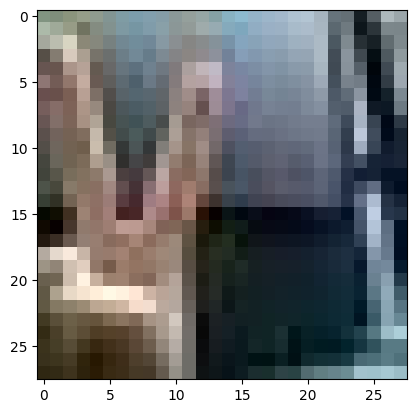

In [196]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1])
print('라벨: ', y_train[1])

# 딥러닝 네트워크 설계하기|

In [197]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# model을 직접 만들어 보세요.
# Hint! model의 입력/출력부에 특히 유의해 주세요. 가위바위보 데이터셋은 MNIST 데이터셋과 어떤 점이 달라졌나요?
n_channel_1 = 16
n_channel_2 = 64
n_dense     = 64
n_train_epoch = 7

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_38 (Conv2D)          (None, 26, 26, 16)        448       
                                                                 
 max_pooling2d_38 (MaxPoolin  (None, 13, 13, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_39 (Conv2D)          (None, 11, 11, 64)        9280      
                                                                 
 max_pooling2d_39 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 flatten_19 (Flatten)        (None, 1600)              0         
                                                                 
 dense_38 (Dense)            (None, 64)              

In [198]:
# model을 학습시키는 코드를 직접 작성해 보세요. 
# Hint! model.compile()과 model.fit()을 사용해 봅시다.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=n_train_epoch)


Epoch 1/7
10/10 [==============================] - 0s 6ms/step - loss: 37.9014 - accuracy: 0.3967
Epoch 2/7
10/10 [==============================] - 0s 6ms/step - loss: 3.2148 - accuracy: 0.6200
Epoch 3/7
10/10 [==============================] - 0s 6ms/step - loss: 0.7539 - accuracy: 0.8267
Epoch 4/7
10/10 [==============================] - 0s 6ms/step - loss: 0.1798 - accuracy: 0.9267
Epoch 5/7
10/10 [==============================] - 0s 6ms/step - loss: 0.1610 - accuracy: 0.9600
Epoch 6/7
10/10 [==============================] - 0s 6ms/step - loss: 0.0730 - accuracy: 0.9700
Epoch 7/7
10/10 [==============================] - 0s 6ms/step - loss: 0.0172 - accuracy: 0.9933


## test 데이터 셋으로 검증 

In [199]:
# x_test, y_test를 만드는 방법은 x_train, y_train을 만드는 방법과 아주 유사합니다.
image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/scissor"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/rock"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/paper"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/"
(x_test, y_test)=load_data(image_dir_path)
x_test_norm = x_test/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_test shape: {}".format(x_test.shape))
print("y_test shape: {}".format(y_test.shape))

100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
학습데이터(x_train)의 이미지 개수는 300 입니다.
x_test shape: (300, 28, 28, 3)
y_test shape: (300,)


In [200]:
# model을 학습시키는 코드를 직접 작성해 보세요.
# Hint! model.evaluate()을 사용해 봅시다.
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 0s - loss: 1.6964 - accuracy: 0.4133 - 103ms/epoch - 10ms/step
test_loss: 1.696413516998291 
test_accuracy: 0.41333332657814026
